# Lab 09 - Generación de Datos Sintéticos con Faker

**Objetivo:** Aprender a generar datos sintéticos utilizando la librería Faker y realizar análisis exploratorio básico.

In [1]:
!pip install Faker

In [2]:
!pip install pandas

In [1]:
#Importamos librerias
from faker import Faker
import pandas as pd
import random

In [2]:
#Creamos una instancia de faker
fake = Faker("es_MX")

In [3]:
#Generamos datos sintéticos: 1000 registros
datos = []
for i in range(1000):
    datos.append({
        "id_usuario": i + 1,
        "nombre": fake.name(),
        "correo": fake.email(),
        "edad": random.randint(18, 65),
        "seguidores": random.randint(100, 50000),
        "plataforma": random.choice(
            ["TikTok", "Instagram", "Youtube"]
        )
    })

In [4]:
# Visualizamos las primeras filas para inspeccionar la estructura de los datos
df = pd.DataFrame(datos)
df.head()

,id_usuario,nombre,correo,edad,seguidores,plataforma
0,1,Mauricio Emiliano Leiva,eleon@example.net,31,29348,Instagram
1,2,Lic. Hernán Delgado,benitezelias@example.com,34,15258,Instagram
2,3,Pedro Cristobal Bravo,mauro11@example.org,54,6228,TikTok
3,4,Sra. Cecilia Arreola,daniel13@example.org,30,25836,TikTok
4,5,Rafaél Jos Puga,abrahamvela@example.com,60,12591,Instagram


In [5]:
#Exploración del Dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id_usuario  1000 non-null   int64
 1   nombre      1000 non-null   str  
 2   correo      1000 non-null   str  
 3   edad        1000 non-null   int64
 4   seguidores  1000 non-null   int64
 5   plataforma  1000 non-null   str  
dtypes: int64(3), str(3)
memory usage: 47.0 KB


In [6]:
#Estadística descriptiva
df.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,1000.000000,1000,1000,1000.000000,1000.000000,1000
unique,NaN,999,999,NaN,NaN,3
top,NaN,Eduardo Mejía,isabela12@example.com,NaN,NaN,Instagram
freq,NaN,2,2,NaN,NaN,350
mean,500.500000,NaN,NaN,41.679000,24959.277000,NaN
std,288.819436,NaN,NaN,14.121522,14324.720648,NaN
min,1.000000,NaN,NaN,18.000000,144.000000,NaN
25%,250.750000,NaN,NaN,29.000000,12722.500000,NaN
50%,500.500000,NaN,NaN,42.000000,24895.000000,NaN
75%,750.250000,NaN,NaN,54.000000,37553.750000,NaN


In [7]:
#Importar librerias para graficar
import seaborn as sns
import matplotlib.pyplot as plt

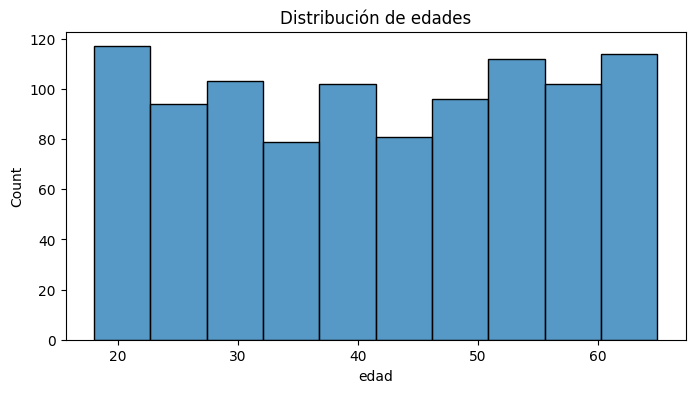

In [8]:
#Distribución de edades
plt.figure(figsize=(8, 4))
sns.histplot(
    df["edad"],
    bins=10
)
plt.title("Distribución de edades")
plt.show()

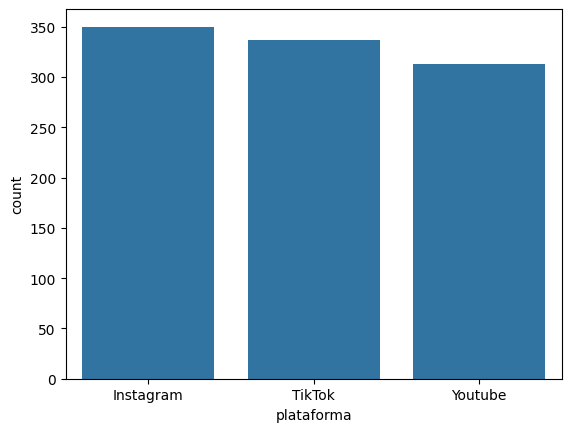

In [9]:
sns.countplot(
    x="plataforma",
    data=df
)
plt.show()

## Contaminación de datos (GIGO - Garbage In, Garbage Out)

In [10]:
#Generamos una copia para contaminarla
df_sucio = df.copy()

In [11]:
#Le colocamos valores nulos
for i in random.sample(range(len(df_sucio)), 5):
    df_sucio.loc[i, "nombre"] = None

In [12]:
# Obtenemos un resumen de las columnas, tipos de datos y valores no nulos
df_sucio.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id_usuario  1000 non-null   int64
 1   nombre      995 non-null    str  
 2   correo      1000 non-null   str  
 3   edad        1000 non-null   int64
 4   seguidores  1000 non-null   int64
 5   plataforma  1000 non-null   str  
dtypes: int64(3), str(3)
memory usage: 47.0 KB


In [13]:
#Edades inválidas
for i in random.sample(range(len(df_sucio)), 5):
    df_sucio.loc[i, "edad"] = -10

In [14]:
# Calculamos estadísticas descriptivas básicas (media, min, max, etc.)
df_sucio.describe()["edad"]

count    1000.000000
mean       41.409000
std        14.552646
min       -10.000000
25%        29.000000
50%        42.000000
75%        54.000000
max        65.000000
Name: edad, dtype: float64

In [15]:
#Seguidores imposibles
for i in random.sample(range(len(df_sucio)), 5):
    df_sucio.loc[i, "seguidores"] = 5000000

In [16]:
# Calculamos estadísticas descriptivas básicas (media, min, max, etc.)
df_sucio.describe()["seguidores"]

count    1.000000e+03
mean     4.986049e+04
std      3.513715e+05
min      1.440000e+02
25%      1.276050e+04
50%      2.501350e+04
75%      3.766500e+04
max      5.000000e+06
Name: seguidores, dtype: float64

In [17]:
#Generamos correos inválidos
for i in random.sample(range(len(df_sucio)), 5):
    df_sucio.loc[i, "correo"] = "correo_invalido"

In [22]:
# Calculamos estadísticas descriptivas básicas (media, min, max, etc.)
df_sucio.describe(include=["object", "str"])

,nombre,correo,plataforma
count,995,1000,1000
unique,994,995,3
top,Eduardo Mejía,correo_invalido,Instagram
freq,2,5,350


In [19]:
df_sucio.isnull().sum()

id_usuario    0
nombre        5
correo        0
edad          0
seguidores    0
plataforma    0
dtype: int64

In [20]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [21]:
# Calculamos estadísticas descriptivas básicas (media, min, max, etc.)
df_sucio.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,1000.00,995,1000,1000.00,1000.00,1000
unique,NaN,994,995,NaN,NaN,3
top,NaN,Eduardo Mejía,correo_invalido,NaN,NaN,Instagram
freq,NaN,2,5,NaN,NaN,350
mean,500.50,NaN,NaN,41.41,49860.49,NaN
std,288.82,NaN,NaN,14.55,351371.51,NaN
min,1.00,NaN,NaN,-10.00,144.00,NaN
25%,250.75,NaN,NaN,29.00,12760.50,NaN
50%,500.50,NaN,NaN,42.00,25013.50,NaN
75%,750.25,NaN,NaN,54.00,37665.00,NaN
